<a href="https://colab.research.google.com/github/Fergit42/Fergit42/blob/main/paneldata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
                      Model Comparison                      
                            Efectos Fijos Efectos Aleatorios
------------------------------------------------------------
Dep. Variable               Productividad      Productividad
Estimator                        PanelOLS      RandomEffects
No. Observations                       50                 50
Cov. Est.                      Unadjusted         Unadjusted
R-squared                          0.9863             0.9871
R-Squared (Within)                 0.9863             0.9757
R-Squared (Between)                0.9742             0.9932
R-Squared (Overall)                0.9755             0.9913
F-statistic                        1367.4             1838.6
P-value (F-stat)                 

<Figure size 1000x600 with 0 Axes>

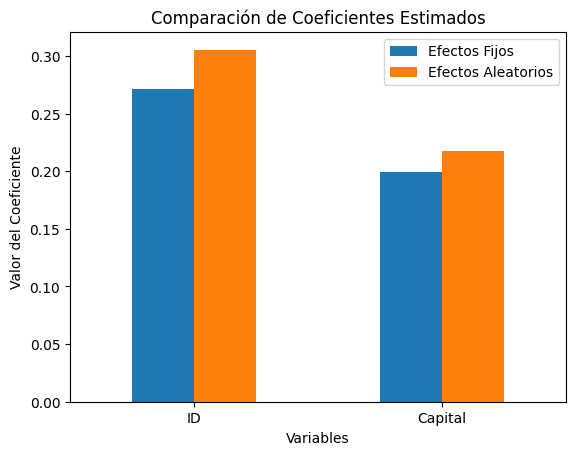

In [ ]:
!pip install linearmodels
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.panel import compare
import matplotlib.pyplot as plt

# Simular datos de panel
np.random.seed(42)
n_firms = 10  # Número de empresas
n_years = 5   # Número de años
index = pd.MultiIndex.from_product([range(n_firms), range(n_years)], names=["Empresa", "Año"])

# Variables simuladas
data = pd.DataFrame(index=index)
data['ID'] = np.random.rand(len(data)) * 100  # Inversiones en I+D
data['Capital'] = np.random.rand(len(data)) * 200
data['Productividad'] = 5 + 0.3 * data['ID'] + 0.2 * data['Capital'] + np.random.randn(len(data)) * 2
data['Efecto_Fijo'] = np.random.randn(n_firms).repeat(n_years)  # Efecto fijo por empresa
data['Productividad'] += data['Efecto_Fijo']

# Preparar datos para modelos de panel
data = data.reset_index()
data['Intercepto'] = 1
panel_data = data.set_index(['Empresa', 'Año'])

# Modelo de efectos fijos
model_fixed = PanelOLS.from_formula('Productividad ~ ID + Capital + EntityEffects', panel_data)
fixed_results = model_fixed.fit()

# Modelo de efectos aleatorios
model_random = RandomEffects.from_formula('Productividad ~ ID + Capital', panel_data)
random_results = model_random.fit()

# Prueba de Hausman
comparison = compare({"Efectos Fijos": fixed_results, "Efectos Aleatorios": random_results})
print(comparison)

# Resumen de resultados
print("Resultados de Efectos Fijos:")
print(fixed_results.summary)
print("\nResultados de Efectos Aleatorios:")
print(random_results.summary)

# Visualización de los coeficientes estimados
plt.figure(figsize=(10, 6))
coef_fixed = fixed_results.params[['ID', 'Capital']]
coef_random = random_results.params[['ID', 'Capital']]

coef_df = pd.DataFrame({
    'Efectos Fijos': coef_fixed,
    'Efectos Aleatorios': coef_random
})
coef_df.plot(kind='bar')
plt.title('Comparación de Coeficientes Estimados')
plt.ylabel('Valor del Coeficiente')
plt.xlabel('Variables')
plt.xticks(rotation=0)
plt.show()
